### convert txt to pkl

In [4]:
    # import igraph as ig
    # import networkx as nx
    # import os
    # import pickle

    # for path in sorted(os.listdir('./real/FINDER')):
    #     file_name = os.path.basename(path)
    #     print(file_name)
    #     g_name = file_name.split('.')[0]
    #     g_type = file_name.split('.')[-1]
    #     if g_type == 'txt':
    #         g = ig.Graph.from_networkx(nx.read_edgelist(path,nodetype=int))
    #         with open(f'{g_name}.pkl', 'wb') as out_f:
    #             pickle.dump(g, out_f)
    

## Graph models

In [5]:
import igraph as ig
import sys
import utils
import importlib
from graphs import graph_models
importlib.reload(graph_models)
importlib.reload(utils)
from utils.plot import plot_graph

#### ER

<Axes: >

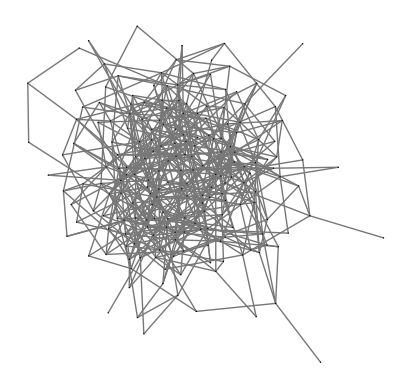

In [6]:
#### BA 
import numpy as np
n = 200
G = ig.Graph.Erdos_Renyi(n, p=np.log(n)/n)
plot_graph(G)

#### BA图

<Axes: >

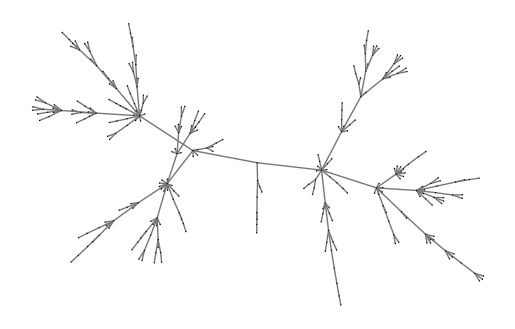

In [7]:
#### BA 
G = ig.Graph.Barabasi(n=300, m=1, directed=False)
plot_graph(G)

#### SBM

<Axes: >

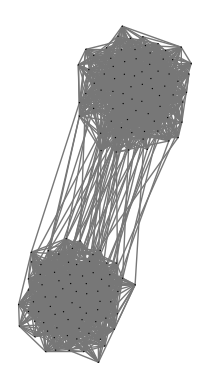

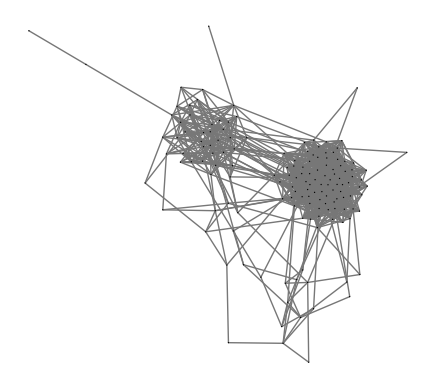

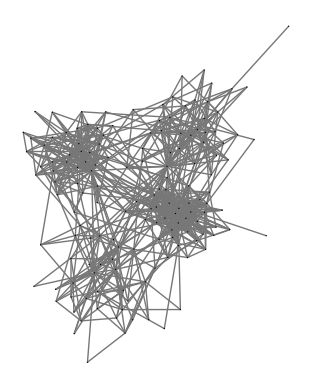

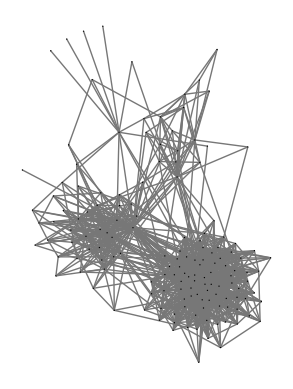

In [8]:
from graphs.graph_models import SBM,DCSBM
G_1 = SBM(N=150,p_in=0.3,p_out = 0.01,num_blocks = 2)
plot_graph(G_1)

G_1 = SBM(N=150,p_in=0.2,p_out = 0.01,num_blocks = 4,unbalanced=True)
plot_graph(G_1)

G_1 = DCSBM(N=150,p_in=0.2,p_out = 0.01,num_blocks = 4)
plot_graph(G_1)

G_1 = DCSBM(N=150,p_in=0.2,p_out = 0.01,num_blocks = 4,unbalanced=True)
plot_graph(G_1)

#### 杠铃图

<Axes: >

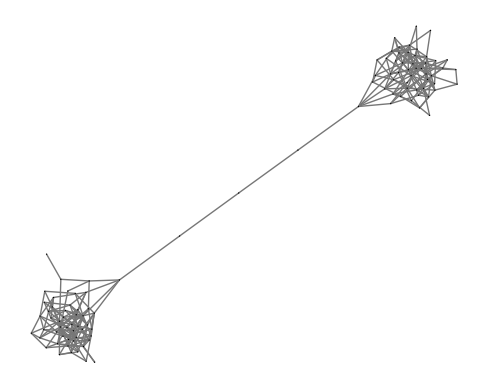

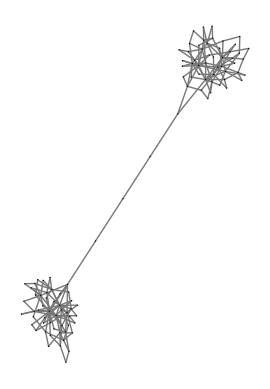

In [9]:
from graphs.graph_models import barbell
G = barbell(N=100,p_in=0.1,path_len=3)
plot_graph(G)

G = barbell(N=100,p_in=0.1,path_len=3,type="BA")
plot_graph(G)

#### 星形社区图

<Axes: >

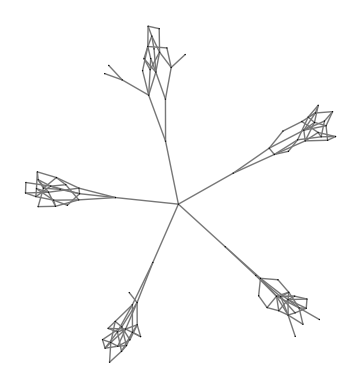

In [10]:
from graphs.graph_models import star_community
G = star_community(N=100,p_in=0.2, num_communities=5)
plot_graph(G)

#### 项链图

<Axes: >

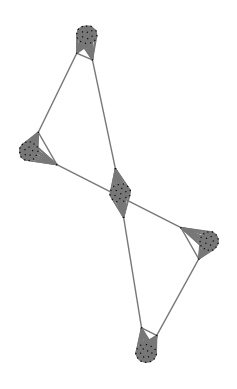

In [11]:
from graphs.graph_models import necklace
G = necklace(N=100, num_cliques=5)
plot_graph(G)

## visualize graphs

In [12]:
import pandas as pd
import numpy as np
def statistics(g):
    leiden_comm = g.community_leiden(
        objective_function="modularity", 
        weights=None, 
        resolution_parameter=1.0, 
        n_iterations=2
    )

    if g.is_connected():
        df = pd.DataFrame(columns=['Num_nodes','Num_edges','AvgDegree', 'Diam', 'AvgShortPath','Clustering Coffe','r','Q'])
        N = g.vcount()
        E = g.vcount()
        AD = np.mean(g.degree())
        CC = g.transitivity_avglocal_undirected() 
        Diam = g.diameter()
        AvgShortPath = g.average_path_length()
        r = g.assortativity_degree()
        Q = leiden_comm.modularity
        df.loc[len(df)] = [N,E,AD, Diam, AvgShortPath,CC, r,Q]
        print(df)
    else: 
        print("unconnected graph")
        df = pd.DataFrame(columns=['Num_nodes','Num_edges','AvgDegree','Clustering Coffe','r','Q'])
        N = g.vcount()
        E = g.vcount()
        AD = np.mean(g.degree())
        CC = g.transitivity_avglocal_undirected() 
        r = g.assortativity_degree()
        Q = leiden_comm.modularity
        df.loc[len(df)] = [N,E,AD,CC, r,Q]
        print(df)

pref_matrix = [[0.3, 0.01], [0.01, 0.3]]
g = ig.Graph.SBM(n=100, pref_matrix=pref_matrix, block_sizes=[50, 50])
statistics(g)

   Num_nodes  Num_edges  AvgDegree  Diam  AvgShortPath  Clustering Coffe  \
0      100.0      100.0      15.24   4.0      2.226869          0.284638   

        r         Q  
0 -0.0046  0.464187  


In [13]:
import igraph as ig
import numpy as np
import sys
import pandas as pd
import os
import importlib
from graphs import graph_models,structural_diversity_analysis
importlib.reload(graph_models)
sys.path.append(r"O:\My_Codes\GD2026\MIND-ND\utils")
from graphs.graph_models import *
from graphs.structural_diversity_analysis import calculate_properties,create_scatter_plot

# topology = np.random.choice(['LPA', 'Copy', 'ER', 'SBM', 'DC-SBM', 'RGG'])
def generate(topology,nrange = "100_200",num=10,is_rewiring=False):
    graphs = []
    n_min = int(nrange.split("_")[0])
    n_max = int(nrange.split("_")[1])
    idx = 0
    
    while idx < num:
        config = {}
        N = np.random.randint(n_min,n_max+1)
        if topology in ['Ring','BA','Copy','LBA']:
            m = int(np.random.choice([1, 2, 3, 4, 5, 6, 8, 10],
                                    p=[1/12, 2/12, 2/12, 2/12, 2/12, 1/12, 1/12, 1/12]))
        if topology in ['SBM','DCSBM','Barbell','StarCom','RingCom']:
            m = int(np.random.choice([3, 4, 5, 6, 8, 10, 12],
                                    p=[3/12, 3/12, 2/12, 2/12, 1/12, 1/24, 1/24]))
        
        if topology == 'Ring':
            g = ig.Graph.Ring(N, directed=False)
        elif topology == '2D-lattice':
            g = ig.Graph.Lattice([5, 5], nei=1, directed=False, mutual=False, circular=False)
        elif topology == 'Regular':
            k = m
            g = random_regular_graph(N,k)
            # g = _ring_based_regular(N,k=m)
        elif topology == 'WS':
            p = np.random.uniform(0.01,0.05)
            g = WS(N,k=m,p=0.2)
        elif topology == 'ER':
            p=((N - 1) * m - 1) / (N * (N - 1))
            g = ig.Graph.Erdos_Renyi(N, p)
            config['N'] = N; config['p'] = p
        elif topology == 'BA':
            g = ig.Graph.Barabasi(N, m, directed=False)
            config['N'] = N; config['m'] = m
        elif topology == 'Copy':
            gamma = 2.5 + np.random.rand()
            g = copying_model(N, m, gamma)
        elif topology == 'LPA':
            gamma = 2.5 + np.random.rand()
            g = LPA(N, m, gamma)
        elif topology == 'SBM':
            num_blocks = 2
            p_in = 0.15
            r = 20
            p_out = p_in/r
            g = SBM(N,p_in,p_out,num_blocks)
            config['N'] = N; config['p_in'] = p_in; config['p_out'] = p_out; config['blocks'] = num_blocks
        elif topology == 'DCSBM':
            num_blocks = np.random.randint(2, 5)
            p_in = min(num_blocks * m / N,0.5)
            r = np.random.choice([10,15,20,25,30,35,40])
            p_out = p_in/r
            g = DCSBM(N,p_in,p_out,num_blocks)
        elif topology == 'RGG':
            r = np.sqrt(np.log(N) / (np.pi * N))
            r = np.random.uniform(1.1,2.0) * r
            g = random_geometric_graph(N, r)
        elif topology == "Barbell":
            p_in = min(2 * m / N,0.5)
            path_len = np.random.randint(1,5)
            config['N'] = N; config['p_in'] = p_in; config['len'] = path_len
            g = barbell(N,p_in,path_len)
        elif topology == "StarCom":
            num_communities = np.random.randint(3,8)
            p_in = min(num_communities * m / N, 0.5)
            g = star_community(N,p_in,num_communities)
            config['N'] = N; config['p_in'] = p_in; config['coms'] = num_communities
        elif topology == "RingCom":
            num_communities = np.random.randint(3,8)
            p_in = min(num_communities * m / N, 0.5)
            print(p_in)
            g = ring_community(N,p_in,num_communities)
            config['N'] = N; config['p_in'] = p_in; config['coms'] = num_communities
        


        elif topology == "Necklace":
            num_cliques = np.random.randint(5,10)
            g = necklace(N,num_cliques)
            config['N'] = N; config['clqs'] = num_cliques
        else:
            raise Exception('Topology not valid!!')

        if g.is_connected():
            g = g  # Already connected, no need to extract
        else:
            g = g.subgraph(max(g.connected_components(), key=len)) 
        
        switch_type = np.random.randint(3) - 1 #[-1,0,1]
        r_coeff = 0.05 if switch_type == 0 \
                else switch_type * np.random.choice([0.15, 0.2, 0.25, 0.3, 0.4, 0.5])
        if topology in ['LPA','Copy']:
            if m==1:
                r_coeff = 0.01 + 0.04 * np.random.rand() if switch_type == 0 else \
                                    switch_type * np.random.choice([0.05, 0.1, 0.15])
        # print("r_target: ",r_coeff," switch_type: ",switch_type)
        
        if is_rewiring:
            g, node_order, ordering, switch_count = rewiring(g,switch_type,r_coeff)
            if g.is_connected():
                g = g  # Already connected, no need to extract
            else:
                g = g.subgraph(max(g.connected_components(), key=len)) 
        
        if g.is_connected() and g.vcount() >= n_min and g.vcount() <= n_max:
            graphs.append((g, topology))
            idx += 1
   
    return graphs

### create train 

generated 100 graphs
Processing 1/100

Creating scatter plot with 100 points...


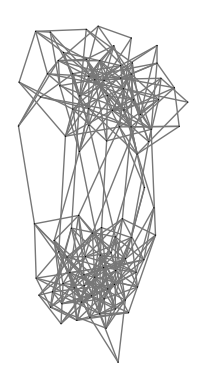

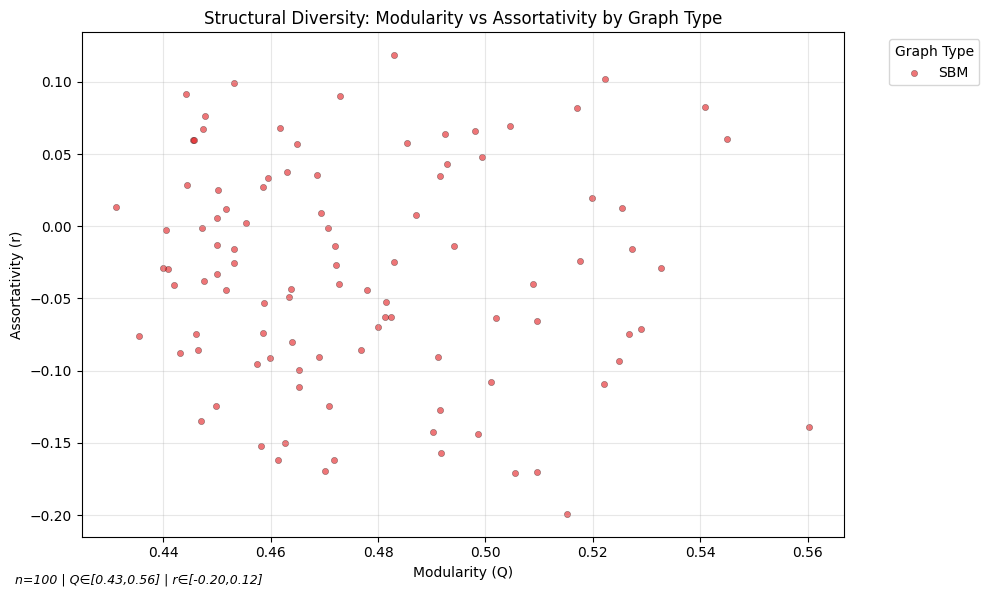

In [14]:
import os

graphs = []
nrange = "50_100"
for idx in range(100):
    # topology = np.random.choice(['Barbell','StarCom','RingCom','SBM'])
    topology = np.random.choice(['SBM'])
    graphs.extend(generate(topology,nrange,1,is_rewiring=False))

print(f"generated {len(graphs)} graphs")

plot_graph(graphs[0][0])

q_values, r_values, labels = calculate_properties(graphs)
create_scatter_plot(q_values, r_values, labels)

dataset_name = "50_100_SBM_2000"
save_dir = f"graphs/train/{dataset_name}"
os.makedirs(save_dir, exist_ok=True)
net_dict = {}
for net_no, (g, topology) in enumerate(graphs):
    net_dict[net_no] = {'adj': np.array(g.get_adjacency().data, dtype=bool)}
    net_dict[net_no]['info'] = {
        'topology': topology,
        'size': g.vcount(),
        'mean_deg': np.mean(g.degree()),
        'assortativity': g.assortativity_degree(),
        # 'config':config
    }
    
    save_name = f"{net_no:05d}_{topology}.pkl"
    # for key,value in config:
    #     save_name += "_"+key + "_"+value
    
#     with open(os.path.join(save_dir,save_name),'wb') as f:
#         pickle.dump(g,f)

# with open(f'{dataset_name}.pkl', 'wb') as out_f:
#     pickle.dump(net_dict, out_f)
    

<Axes: >

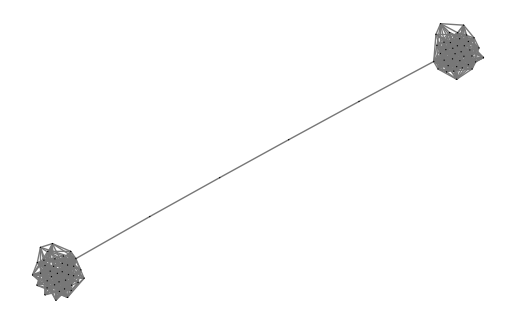

In [18]:
plot_graph(graphs[2][0])

### create valid

In [8]:
sys.path.append(r"O:\My_Codes\GD2026\MIND-ND\utils")
from plot import plot_graph

save_dir = "valid_20260104"
net_dict = {}

for topology in ['BA','WS','ER','Barbell','Necklace','Ring','SBM','DCSBM']:
    nrange = '100_400'
    graphs = generate(topology,nrange,num=10)
    for net_no, (g, topology) in enumerate(graphs):
        with open(os.path.join(save_dir,f"{net_no:05d}_{topology}.pkl"),'wb') as f:
            pickle.dump(g,f)


## synthetic data analyze

   Num_nodes  Num_edges  AvgDegree  ...  Clustering Coffe         r         Q
0      115.0      115.0   6.817391  ...          0.189253 -0.062342  0.663783

[1 rows x 8 columns]
   Num_nodes  Num_edges  AvgDegree  ...  Clustering Coffe         r         Q
0      130.0      130.0   2.953846  ...          0.013814  0.016349  0.669651

[1 rows x 8 columns]
   Num_nodes  Num_edges  AvgDegree  ...  Clustering Coffe         r         Q
0       98.0       98.0   4.510204  ...          0.163701  0.064105  0.636852

[1 rows x 8 columns]
   Num_nodes  Num_edges  AvgDegree  ...  Clustering Coffe         r         Q
0      128.0      128.0    3.59375  ...          0.028606 -0.051413  0.551758

[1 rows x 8 columns]
   Num_nodes  Num_edges  AvgDegree  ...  Clustering Coffe         r         Q
0       87.0       87.0    6.45977  ...          0.181451  0.070807  0.574803

[1 rows x 8 columns]
   Num_nodes  Num_edges  AvgDegree  ...  Clustering Coffe         r         Q
0      128.0      128.0     4.31

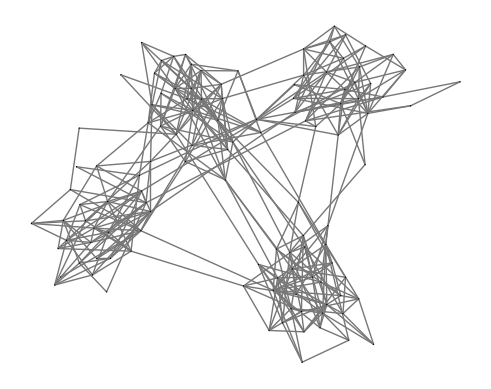

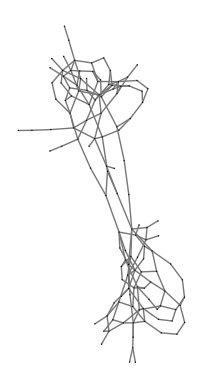

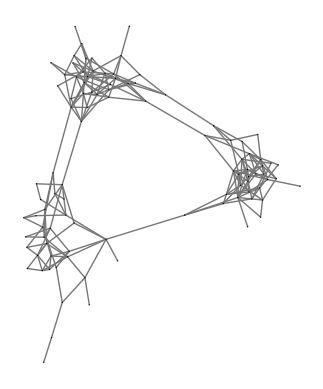

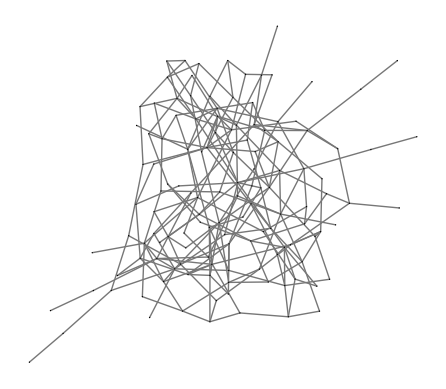

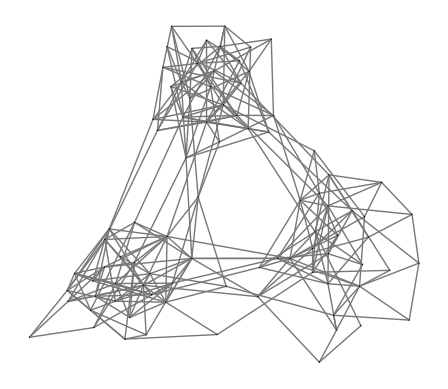

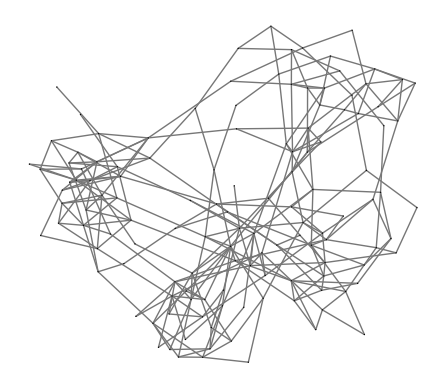

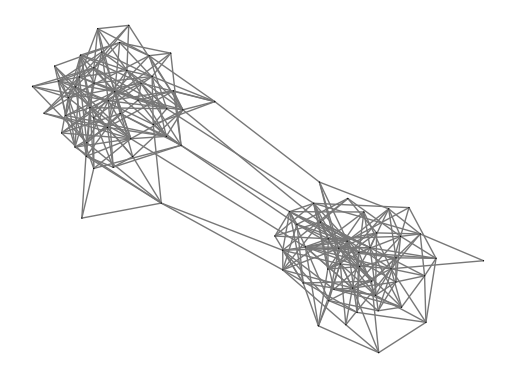

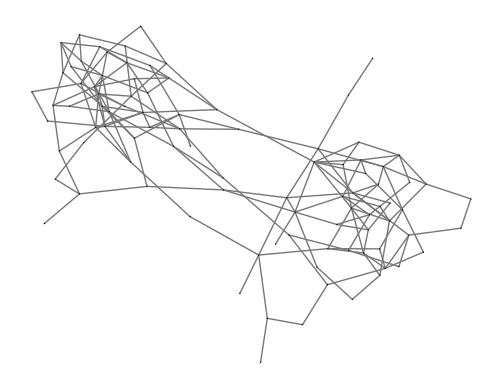

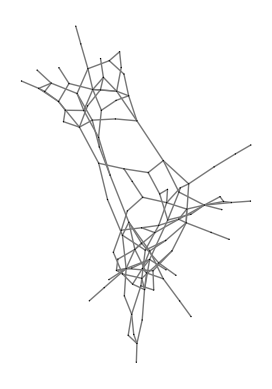

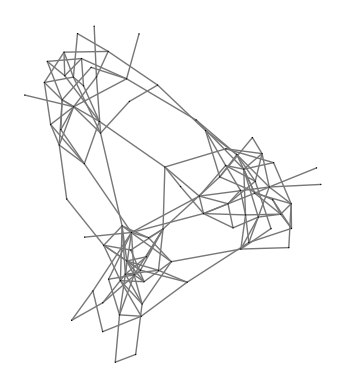

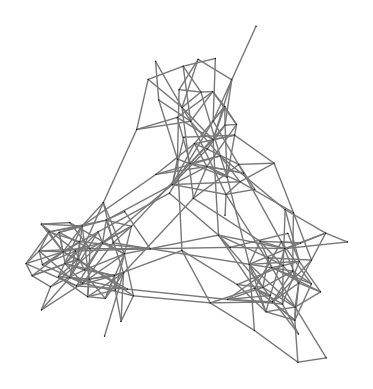

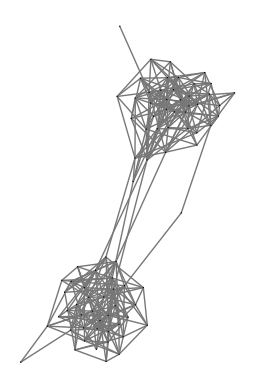

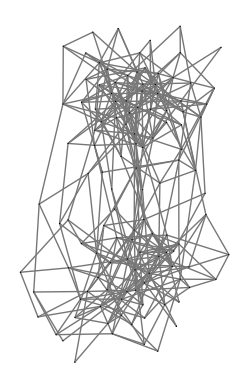

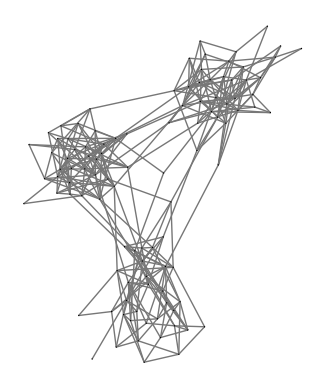

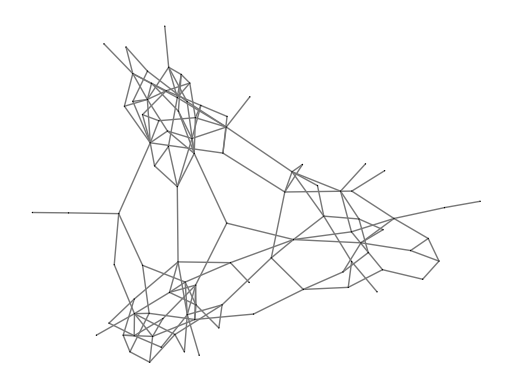

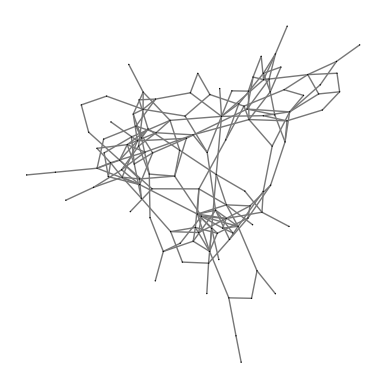

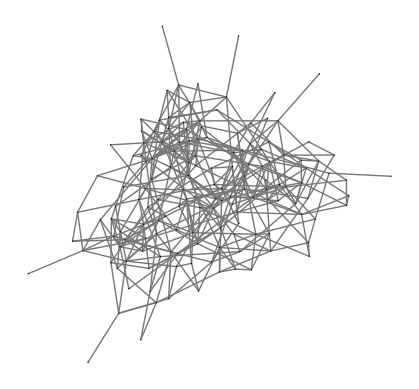

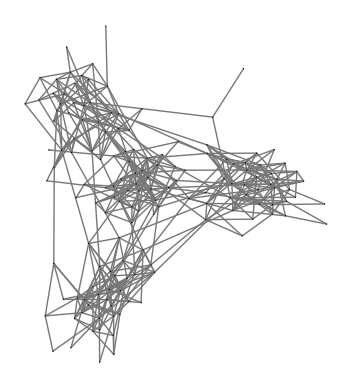

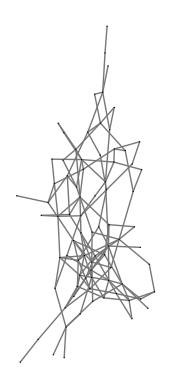

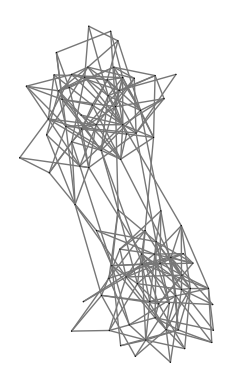

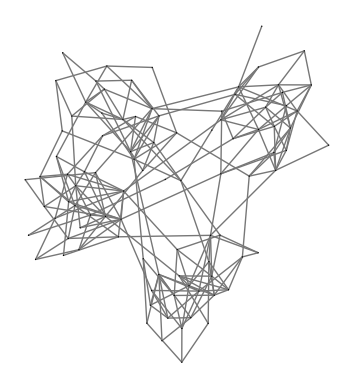

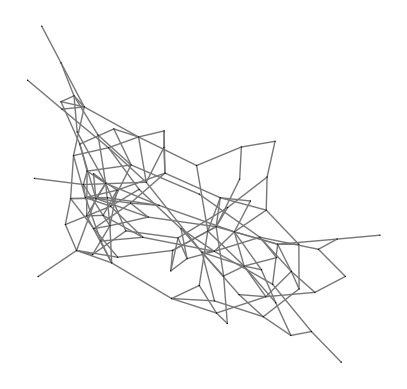

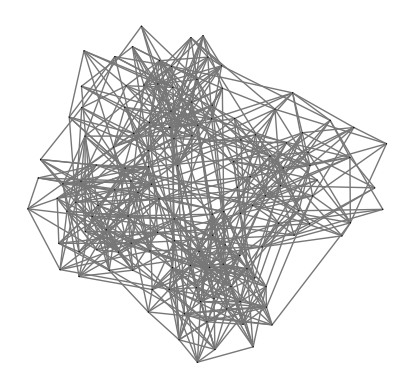

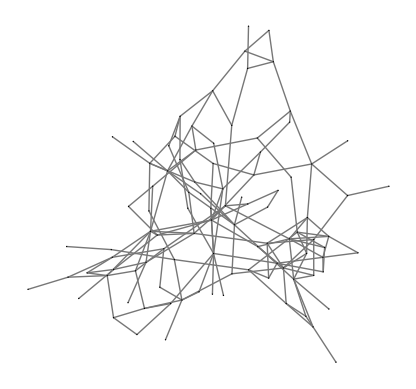

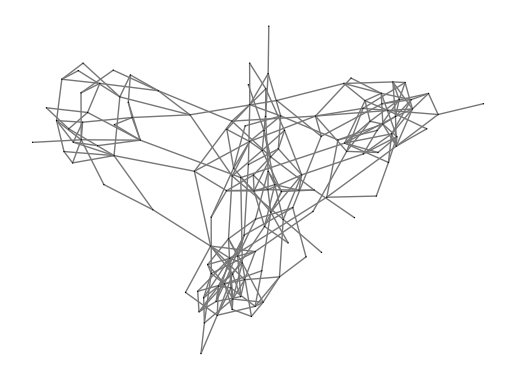

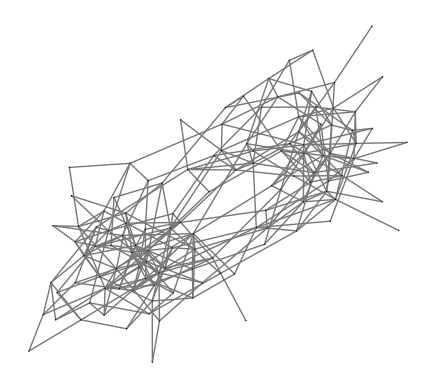

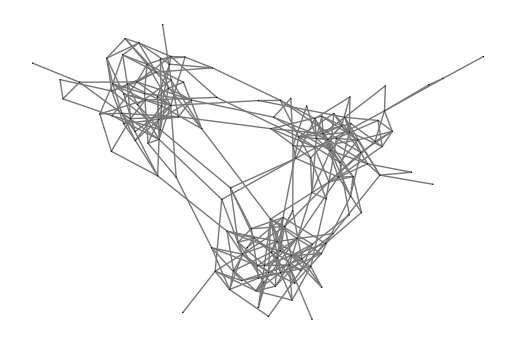

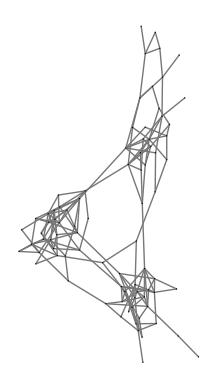

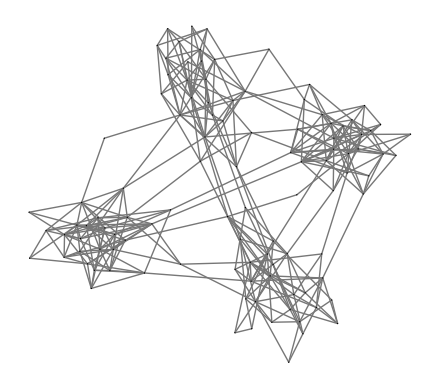

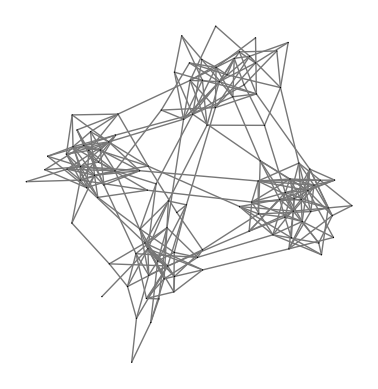

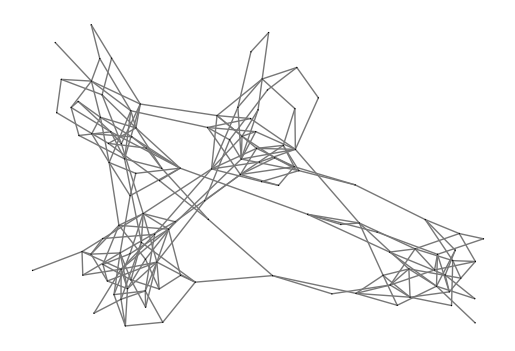

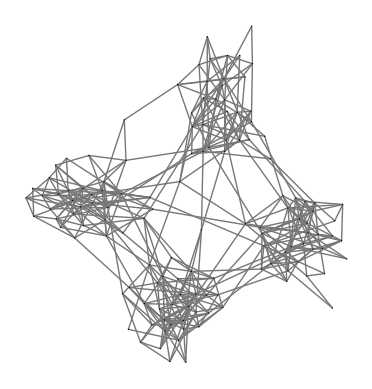

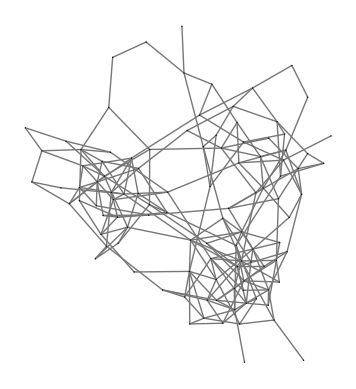

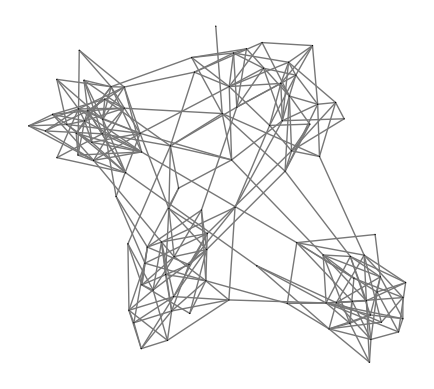

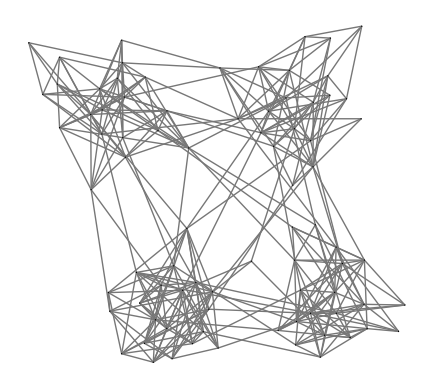

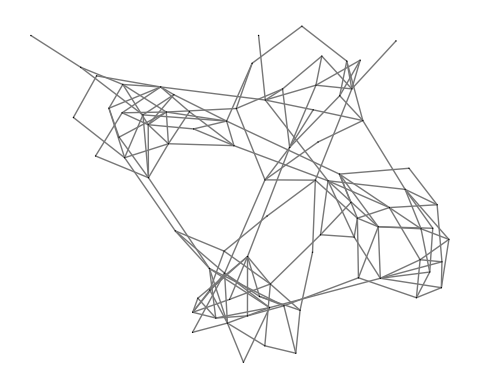

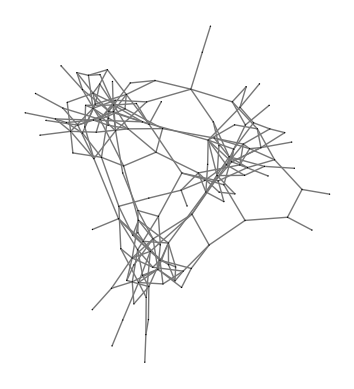

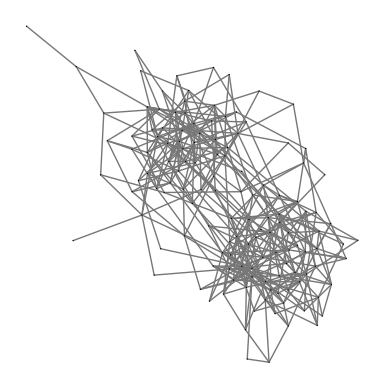

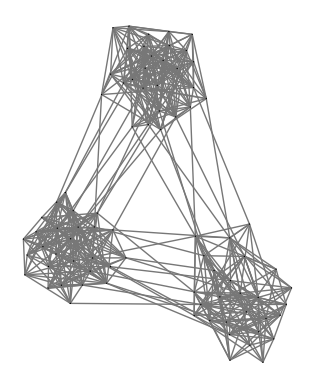

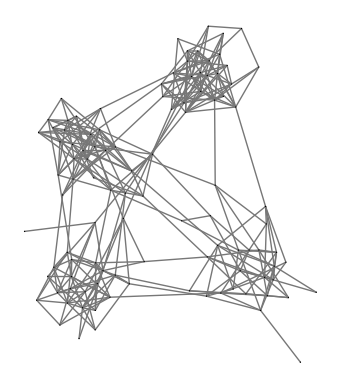

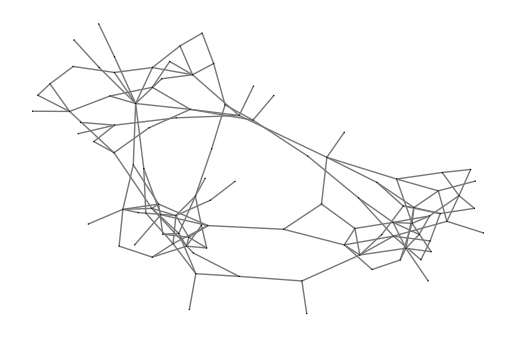

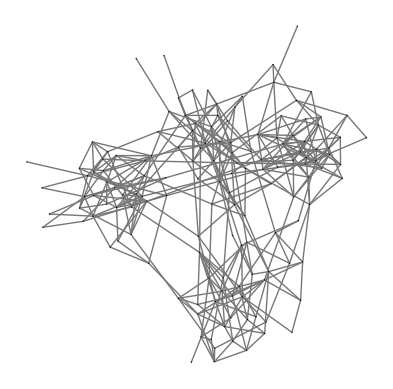

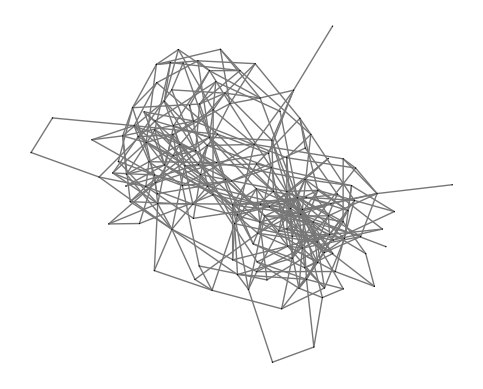

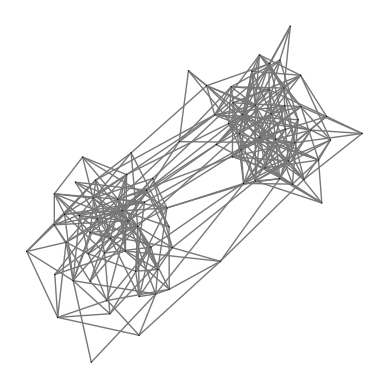

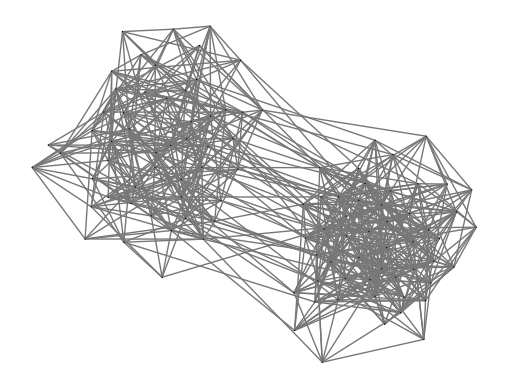

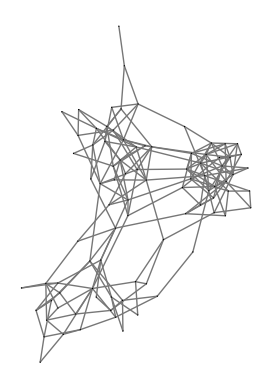

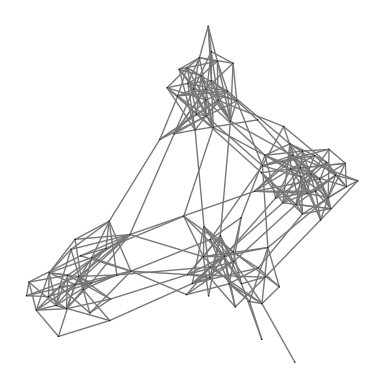

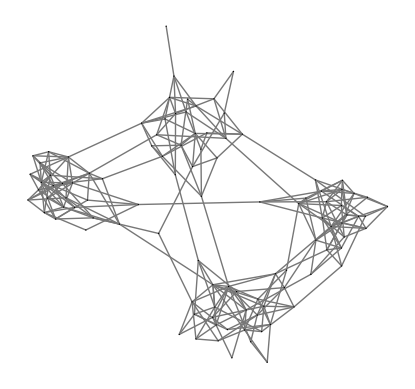

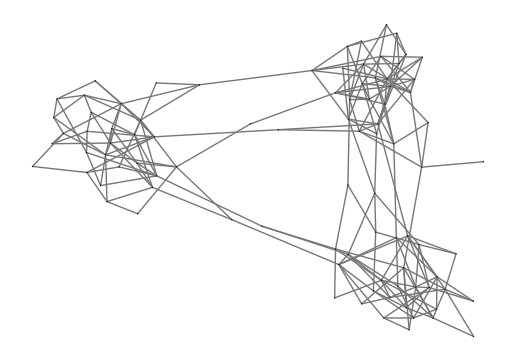

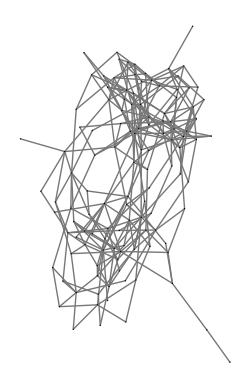

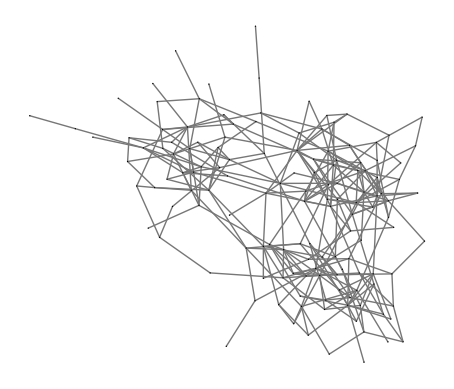

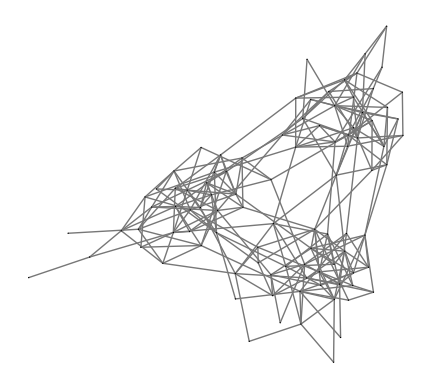

In [89]:
from common import load_g
from plot import plot_graph
data_dir = "graphs/train/80_150_BR_2000"
for p in os.listdir(data_dir)[:200]:
    data_path = os.path.join(data_dir,p)
    if 'SBM' in data_path:
        g = load_g(data_path,name=p) 
        statistics(g)
        plot_graph(g)

## spectral analyze

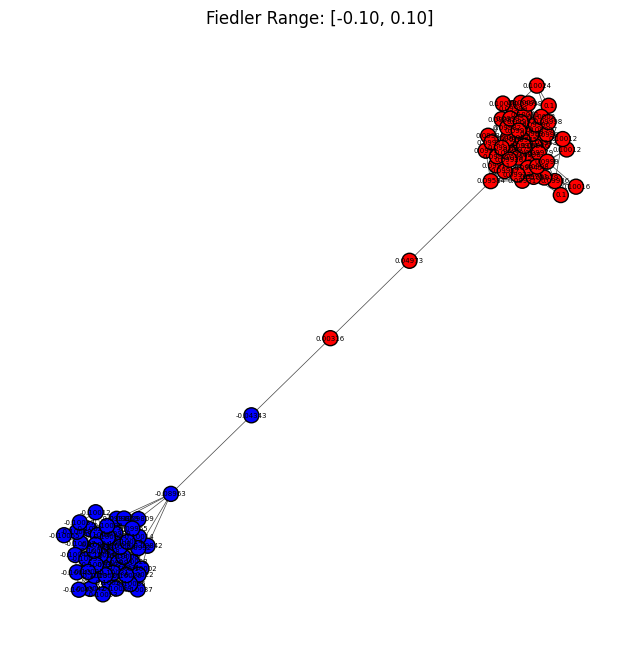

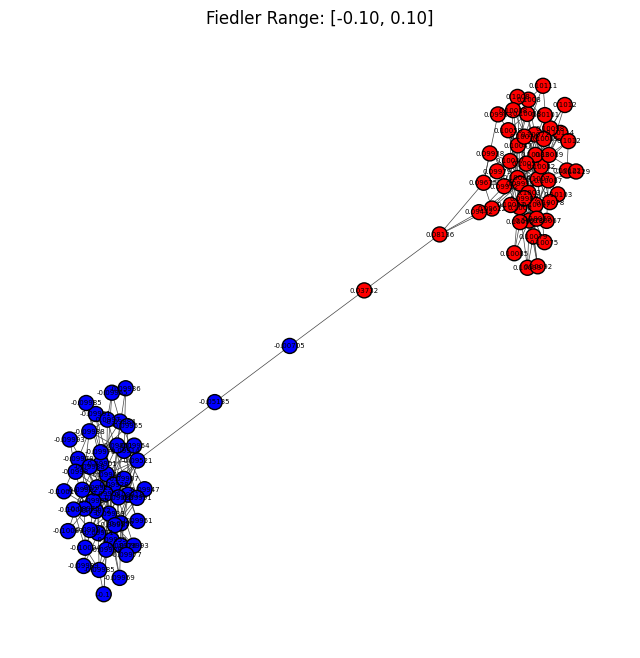

In [11]:
import igraph as ig
import numpy as np
np.set_printoptions(precision=5)
from scipy.linalg import eigh
import matplotlib.pyplot as plt

def plot_fiedler(g):
    # 1. Calculate Laplacian and Fiedler Vector
    L = np.array(g.laplacian())
    vals, vecs = eigh(L)
    fiedler_vec = np.array(vecs[:, 1]) # Second column is λ2's eigenvector
    fiedler_vec = np.around(fiedler_vec, decimals=5)

    # 2. Setup Visualization
    # Color nodes by their value in the Fiedler vector (Red to Blue)
    layout = g.layout_fruchterman_reingold()
    
    # Map Fiedler values to a color gradient
    fig, ax = plt.subplots(figsize=(8, 8))
    ig.plot(
        g, 
        target=ax,
        layout=layout,
        vertex_color=[ "red" if x > 0 else "blue" for x in fiedler_vec ],
        vertex_size=15,
        edge_width=0.5,
        vertex_label=fiedler_vec,
        vertex_label_size = 5
        
    )
    plt.title(f"Fiedler Range: [{min(fiedler_vec):.2f}, {max(fiedler_vec):.2f}]")
    plt.show()

# Generate a Scale-Free Barbell for visualization
from graphs.graph_models import barbell
g = barbell(N=100,p_in=0.15,path_len=3,type="ER")
plot_fiedler(g)

g = barbell(N=100,p_in=0.15,path_len=3,type="BA")
plot_fiedler(g)

在一个社区环中，会看到一组小特征值 $(\lambda_2, \lambda_3, \dots, \lambda_k)$.

这些k特征值都非常接近零。接近零的特征值数量描述了网络中存在多少几乎断开的社区。

\lambda_1 总是为0，表示最大连通子图（如果图是连通图，那就是图本身）

\lambda_k 和 \lambda_{k+1} 会有很大差距

First 7 eigenvalues:
λ1: 0.00000
λ2: 0.05464
λ3: 0.05583
λ4: 0.13043
λ5: 0.13753
λ6: 0.16342
λ7: 1.31795


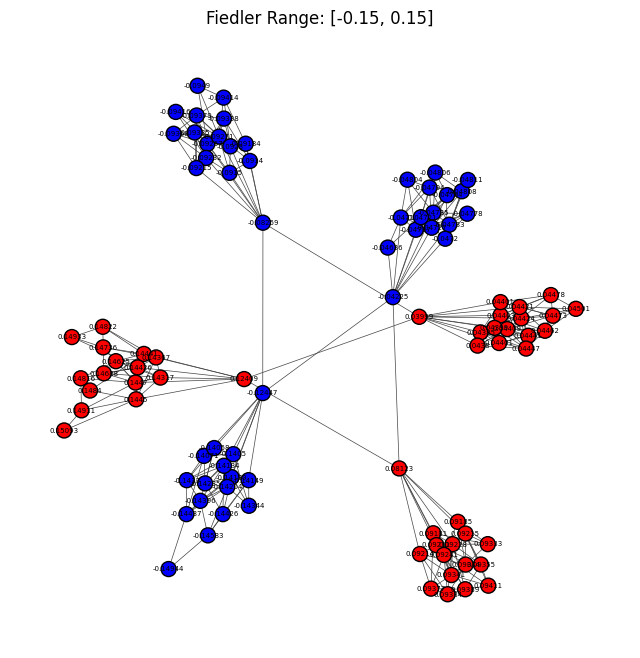

In [18]:
from graphs.graph_models import ring_community
num_communities = 6
g = ring_community(N = 100,p_in=0.4, num_communities=num_communities)
# Calculate Eigenvalues
L = np.array(g.laplacian())
vals = eigh(L, eigvals_only=True)

print(f"First {num_communities+1} eigenvalues:")
for i in range(num_communities+1):
    print(f"λ{i+1}: {vals[i]:.5f}")

plot_fiedler(g)

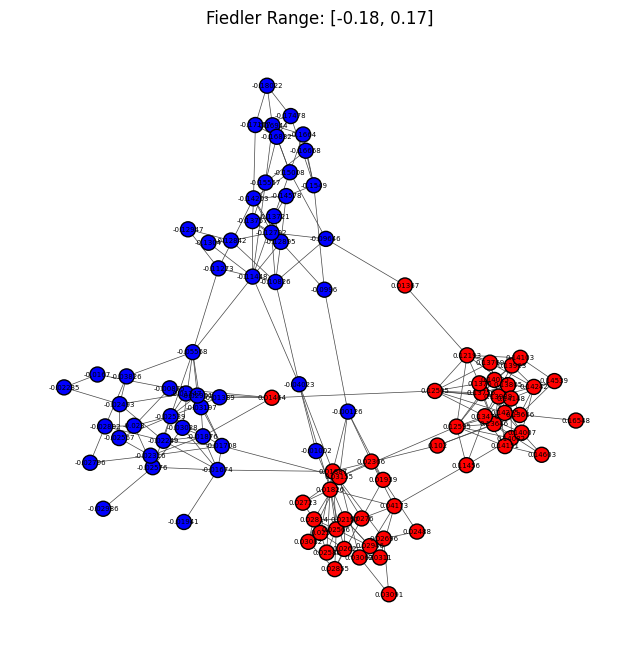

In [26]:
from graphs.graph_models import SBM
g = SBM(N=100,p_in=0.2,p_out=0.003,num_blocks=4)
plot_fiedler(g)

## real dataset analyze

In [ ]:
sys.path.append(r"O:\My_Codes\GD2026\MIND-ND\utils")
from common import load_g
# # data_path = "real/FINDER/Gnutella31.pkl"
data_path = "real/social/soc-Epinions1.pkl"
g = load_g(data_path,name='test') 
statistics(g)

In [58]:
import igraph as ig
import sys
sys.path.append(r"O:\My_Codes\GD2026\MIND-ND\utils")
from common import load_g
# data_path = "real/FINDER/Crime.pkl"
data_path = "real/bio/maayan-figeys.pkl"
 
g = load_g(data_path,name='test') 
# g = ig.Graph.Barabasi(n=50, m=4, directed=False)
statistics(g)

unconnected graph
   Num_nodes  Num_edges  AvgDegree  Clustering Coffe         r         Q
0     2239.0     2239.0   5.745422          0.070995 -0.330527  0.508925


In [ ]:
import os
import pickle
import igraph as ig
graph_dir = 'graphs/train/200_300_ER_LPA_COPY_SBM_LBR'

net_dict = {}
for net_no,path in enumerate(sorted(os.listdir(graph_dir))):
    with open(os.path.join(graph_dir,path), 'rb') as f:
        g_dict = pickle.load(f)
        net_dict[net_no] = g_dict 
    # print(g)
    # ig.summary(g)
save_name = f"{os.path.basename(graph_dir)}.pkl"
with open(save_name,'wb') as f:
    pickle.dump(net_dict,f)

#### combine datasets

In [18]:
import pickle

# Load all dictionaries
dicts = []
filenames = ['switched_graphs_1218.pkl', 'switched_graphs_1218_2.pkl', '100_200_ER_LPA_COPY_10000.pkl']

for filename in filenames:
    with open(filename, 'rb') as f:
        dicts.append(pickle.load(f))

# Combine with sequential keys
combined_net_dict = {}
current_key = 0

for net_dict in dicts:
    for value in net_dict.values():
        combined_net_dict[current_key] = value
        current_key += 1

# Save combined dictionary
with open('combined_graphs.pkl', 'wb') as f:
    pickle.dump(combined_net_dict, f)

print(f"Combined {sum(len(d) for d in dicts)} graphs into {len(combined_net_dict)} entries")


Combined 6603 graphs into 6603 entries
